## Imports

In [19]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

# cheap models are gpt-5-nano, gpt-4.1-nano, gpt-4o-mini

In [2]:
## model initialization testing
model = init_chat_model(model = 'openai:gpt-5-nano')
result = model.invoke("Write a joke on penguins")
print(result)

content='Why don’t penguins like talking to strangers at parties? They find it hard to break the ice.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 734, 'prompt_tokens': 12, 'total_tokens': 746, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 704, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-E0otVgdXmvxWgSUvf6XiwLUzYR9cv', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019f5699-be53-77d3-8df0-53e39431f069-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 12, 'output_tokens': 734, 'total_tokens': 746, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 704}}


## Create Evaluation Schema for Structured Output

In [13]:
class EvaluateEssay(BaseModel):
    feedback: str = Field(description="Concise feedback with strength and weakness on the essay.")
    score: int = Field(description="Score the essay in a scale of 1-10",ge=1,le=10)

In [14]:
# model with Structured Output
structured_model = model.with_structured_output(EvaluateEssay)

## Testing the Evaluate Schema with structured output

In [15]:
# Test the Evaluation Schema
sample_essay = """ 
Artificial Intelligence (AI) is changing the banking sector in many ways. Today, banks use AI to improve customer service, detect fraud, and make faster decisions. Many banks have introduced chatbots that can answer customer questions at any time, reducing the need for people to visit branches. AI is also used to analyse customer spending patterns and suggest suitable financial products.
Another important use of AI is in fraud detection. AI systems can identify unusual transactions within seconds and alert the bank before major losses happen. This helps both the bank and its customers. AI also supports loan approval by analysing customer data quickly. While this makes the process faster, banks should still ensure that decisions are fair and transparent.
However, AI also brings some challenges. The technology depends on large amounts of data, so protecting customer privacy is very important. Sometimes AI models may make mistakes or produce biased results if the training data is not balanced. Banks needs to monitor these systems regularly to avoid such problems.
Overall, AI has made banking more efficient and convenient. It saves time, reduces operational costs, and improves customer experience. Even though there are some risks, AI will continue to play a bigger role in the banking industry, and its impact is likely to grow in the coming years.
"""

sample_prompt = f"Evaluate the overall quality of the following essay and provide feedback and assign score out of 10.\n{sample_essay}"
sample_output = structured_model.invoke(sample_prompt)

In [16]:
print(sample_prompt)

Evaluate the overall quality of the following essay and provide feedback and assign score out of 10.
 
Artificial Intelligence (AI) is changing the banking sector in many ways. Today, banks use AI to improve customer service, detect fraud, and make faster decisions. Many banks have introduced chatbots that can answer customer questions at any time, reducing the need for people to visit branches. AI is also used to analyse customer spending patterns and suggest suitable financial products.
Another important use of AI is in fraud detection. AI systems can identify unusual transactions within seconds and alert the bank before major losses happen. This helps both the bank and its customers. AI also supports loan approval by analysing customer data quickly. While this makes the process faster, banks should still ensure that decisions are fair and transparent.
However, AI also brings some challenges. The technology depends on large amounts of data, so protecting customer privacy is very impo

In [17]:
print(sample_output.score)
print(sample_output.feedback)

6
Strengths: Clear focus on how AI is used in banking (customer service, fraud detection, loan decisions) and a balanced note on potential downsides. The essay has a logical structure with an introduction, discussion of benefits, challenges, and a closing outlook, and uses specific examples (chatbots, anomaly detection). It communicates a generally balanced view and shows awareness of fairness and transparency concerns. Areas for improvement: minor grammar/consistency issues (e.g., "Banks needs" should be "Banks need"). Some wording choices are repetitive and could be tightened for fluency. The argument would be stronger with more concrete detail or data (e.g., brief statistics or case examples), and a deeper discussion of governance, regulatory considerations, and issues like model explainability, data quality, and bias mitigation. Consider improving transitions between ideas to avoid repetition and ensure a fully polished conclusion that highlights actionable implications. Overall, a

## Create Schema for graph

In [22]:
class EssayGrader(TypedDict):
    essay: str
    language_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int],operator.add]
    avg_score: float

## Define Node functions

In [28]:
def language_feedback(state: EssayGrader):
    prompt = f"Evaluate the language quality of the following essay, provide a concise feedback with strength and weakness, and assign score out of 10.\n{state['essay']}"
    output = structured_model.invoke(prompt)
    return {'language_feedback':output.feedback,
            'individual_scores':[output.score]}

def clarity_feedback(state: EssayGrader):
    prompt = f"Evaluate the thought clarity of the following essay, provide a concise feedback with strength and weakness, and assign score out of 10.\n{state['essay']}"
    output = structured_model.invoke(prompt)
    return {'clarity_feedback':output.feedback,
            'individual_scores':[output.score]}

def overall_feedback(state: EssayGrader):
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    output = model.invoke(prompt)
    return {'overall_feedback':output.content}

def avg_score(state: EssayGrader)-> float:
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])
    return {'avg_score':avg_score}

## Create graph object

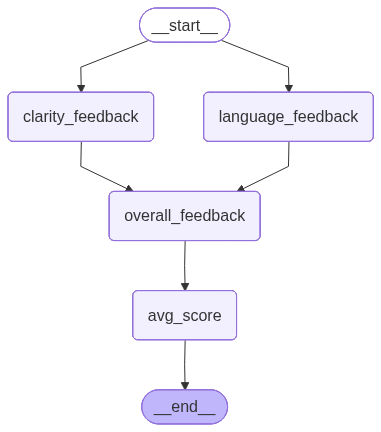

In [29]:
# initialize graph
graph = StateGraph(EssayGrader)

# add nodes
graph.add_node("language_feedback", language_feedback)
graph.add_node("clarity_feedback", clarity_feedback)
graph.add_node("overall_feedback", overall_feedback)
graph.add_node("avg_score", avg_score)

# add edges
graph.add_edge(START,"language_feedback")
graph.add_edge(START,"clarity_feedback")
graph.add_edge("language_feedback","overall_feedback")
graph.add_edge("clarity_feedback","overall_feedback")
graph.add_edge("overall_feedback","avg_score")
graph.add_edge("avg_score",END)

# compile graph
workflow = graph.compile()

## Visualizing the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

## Usage of Graph

### Example essay 1

In [30]:
essay = """ 
        Artificial Intelligence (AI) is changing the banking sector in many ways. Today, banks use AI to improve customer service, detect fraud, and make faster decisions. Many banks have introduced chatbots that can answer customer questions at any time, reducing the need for people to visit branches. AI is also used to analyse customer spending patterns and suggest suitable financial products.
        Another important use of AI is in fraud detection. AI systems can identify unusual transactions within seconds and alert the bank before major losses happen. This helps both the bank and its customers. AI also supports loan approval by analysing customer data quickly. While this makes the process faster, banks should still ensure that decisions are fair and transparent.
        However, AI also brings some challenges. The technology depends on large amounts of data, so protecting customer privacy is very important. Sometimes AI models may make mistakes or produce biased results if the training data is not balanced. Banks needs to monitor these systems regularly to avoid such problems.
        Overall, AI has made banking more efficient and convenient. It saves time, reduces operational costs, and improves customer experience. Even though there are some risks, AI will continue to play a bigger role in the banking industry, and its impact is likely to grow in the coming years.
        """

initial_state = {'essay': essay}
final_state = workflow.invoke(initial_state)

In [31]:
final_state

{'essay': ' \n        Artificial Intelligence (AI) is changing the banking sector in many ways. Today, banks use AI to improve customer service, detect fraud, and make faster decisions. Many banks have introduced chatbots that can answer customer questions at any time, reducing the need for people to visit branches. AI is also used to analyse customer spending patterns and suggest suitable financial products.\n        Another important use of AI is in fraud detection. AI systems can identify unusual transactions within seconds and alert the bank before major losses happen. This helps both the bank and its customers. AI also supports loan approval by analysing customer data quickly. While this makes the process faster, banks should still ensure that decisions are fair and transparent.\n        However, AI also brings some challenges. The technology depends on large amounts of data, so protecting customer privacy is very important. Sometimes AI models may make mistakes or produce biased 

### Example essay 2

In [34]:
essay2 = """
            Artificial Intelligence or AI is now used in many banks. It help banks do many works faster and sometime better. Banks use AI for talking with customers by chatbot and also to catch frauds. If someone do strange transaction then AI can tell the bank very fast. This is good because money can be save.
            But AI is also not always correct. Sometimes it makes wrong decision because the data was not good. I think banks should check it again by people. Long time ago banks did not have AI and peoples waited in long lines. Now things are faster but also little confusing for old peoples. Also computers are everywhere now, not only in banks but schools and shops too, so the world is changing very much. In the end AI is good for banking but it have some problems also. Maybe in future it will become more smarter and everyone will use it.
        """

initial_state = {'essay': essay2}
final_state = workflow.invoke(initial_state)

In [35]:
final_state

{'essay': '\n            Artificial Intelligence or AI is now used in many banks. It help banks do many works faster and sometime better. Banks use AI for talking with customers by chatbot and also to catch frauds. If someone do strange transaction then AI can tell the bank very fast. This is good because money can be save.\n            But AI is also not always correct. Sometimes it makes wrong decision because the data was not good. I think banks should check it again by people. Long time ago banks did not have AI and peoples waited in long lines. Now things are faster but also little confusing for old peoples. Also computers are everywhere now, not only in banks but schools and shops too, so the world is changing very much. In the end AI is good for banking but it have some problems also. Maybe in future it will become more smarter and everyone will use it.\n        ',
 'language_feedback': "Strengths: clear topic about AI in banking with a balanced view and concrete examples (chatb